# UNet Prediction — Average Hausdorff Distance Evaluation

Computes the **Average Hausdorff Distance** between the UNet prediction mask
and the ground-truth label for a single sample.

**Definition:**
- `d(A→B) = mean( min_dist(a, B) for a in A )`
- `d(B→A) = mean( min_dist(b, A) for b in B )`
- `avg_hausdorff(A, B) = (d(A→B) + d(B→A)) / 2`

Point sets are the **foreground pixel coordinates** of each binary mask.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.spatial import cKDTree

from neural_reconstruction.core.evaluation.metrics import (
    compute_average_hausdorff_distance,
)

print("Imports OK")

Imports OK


## 2. Configuration

In [2]:
DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../output/unet")

SAMPLE_ID      = "S1585-2_a"
PRED_THRESHOLD = 127   # predictions saved as 0/255 PNG
LABEL_THRESHOLD = 127

label_path = DATA_DIR / SAMPLE_ID / "label.png"
pred_path  = OUTPUT_DIR / f"{SAMPLE_ID}_pred.png"

print(f"Sample     : {SAMPLE_ID}")
print(f"Label path : {label_path}")
print(f"Pred  path : {pred_path}")

Sample     : S1585-2_a
Label path : ../data/S1585-2_a/label.png
Pred  path : ../output/unet/S1585-2_a_pred.png


## 3. Load Images

In [3]:
label_raw = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
pred_raw  = cv2.imread(str(pred_path),  cv2.IMREAD_GRAYSCALE)

assert label_raw is not None, f"Could not load: {label_path}"
assert pred_raw  is not None, f"Could not load: {pred_path}"

label_mask = label_raw > LABEL_THRESHOLD   # bool (H, W)
pred_mask  = pred_raw  > PRED_THRESHOLD    # bool (H, W)

print(f"Image shape     : {label_raw.shape}")
print(f"Label foreground: {label_mask.sum():,} px")
print(f"Pred  foreground: {pred_mask.sum():,} px")

Image shape     : (2867, 5632)
Label foreground: 30,053 px
Pred  foreground: 53,707 px


## 4. Extract Foreground Points

Each foreground pixel becomes a point `[row, col]` (i.e. `[y, x]`).

In [4]:
# np.argwhere returns (N, 2) array of [row, col] for True pixels
label_pts = np.argwhere(label_mask).astype(np.float32)   # (M, 2)
pred_pts  = np.argwhere(pred_mask).astype(np.float32)    # (N, 2)

print(f"Label point set : {label_pts.shape}")
print(f"Pred  point set : {pred_pts.shape}")

Label point set : (30053, 2)
Pred  point set : (53707, 2)


## 5. Average Hausdorff Distance

In [5]:
avg_hd, d_pred_to_label, d_label_to_pred = compute_average_hausdorff_distance(
    pred_pts, label_pts, return_components=True
)

print(f"d(Pred → Label) : {d_pred_to_label:.4f} px  (precision proxy)")
print(f"d(Label → Pred) : {d_label_to_pred:.4f} px  (recall proxy)")
print(f"Avg Hausdorff   : {avg_hd:.4f} px")

d(Pred → Label) : 45.8456 px  (precision proxy)
d(Label → Pred) : 1.0491 px  (recall proxy)
Avg Hausdorff   : 23.4474 px


## 6. Pixel-level Metrics (for reference)

In [6]:
tp = int(( pred_mask &  label_mask).sum())
fp = int(( pred_mask & ~label_mask).sum())
fn = int((~pred_mask &  label_mask).sum())

dice      = 2 * tp / max(2 * tp + fp + fn, 1)
precision = tp / max(tp + fp, 1)
recall    = tp / max(tp + fn, 1)
iou       = tp / max(tp + fp + fn, 1)

print(f"TP: {tp:,}   FP: {fp:,}   FN: {fn:,}")
print(f"Dice      : {dice:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"IoU       : {iou:.4f}")

TP: 22,949   FP: 30,758   FN: 7,104
Dice      : 0.5480
Precision : 0.4273
Recall    : 0.7636
IoU       : 0.3774


## 7. Distance Heatmap

For every foreground pixel in the **label**, visualize its distance to the
nearest pixel in the **prediction** (`d(Label → Pred)`).

In [7]:
# Build KD-tree on prediction points for fast nearest-neighbor lookup
tree_pred = cKDTree(pred_pts)
dist_label_to_pred, _ = tree_pred.query(label_pts, workers=-1)

tree_label = cKDTree(label_pts)
dist_pred_to_label, _ = tree_label.query(pred_pts, workers=-1)

# Build distance images for visualization
h, w = label_mask.shape
dist_img_label = np.zeros((h, w), dtype=np.float32)
dist_img_pred  = np.zeros((h, w), dtype=np.float32)

rows_l, cols_l = label_pts[:, 0].astype(int), label_pts[:, 1].astype(int)
rows_p, cols_p = pred_pts[:, 0].astype(int),  pred_pts[:, 1].astype(int)

dist_img_label[rows_l, cols_l] = dist_label_to_pred
dist_img_pred [rows_p, cols_p] = dist_pred_to_label

vmax = np.percentile(
    np.concatenate([dist_label_to_pred, dist_pred_to_label]), 98
)
print(f"98th-percentile distance cap for colormap: {vmax:.1f} px")

98th-percentile distance cap for colormap: 282.1 px


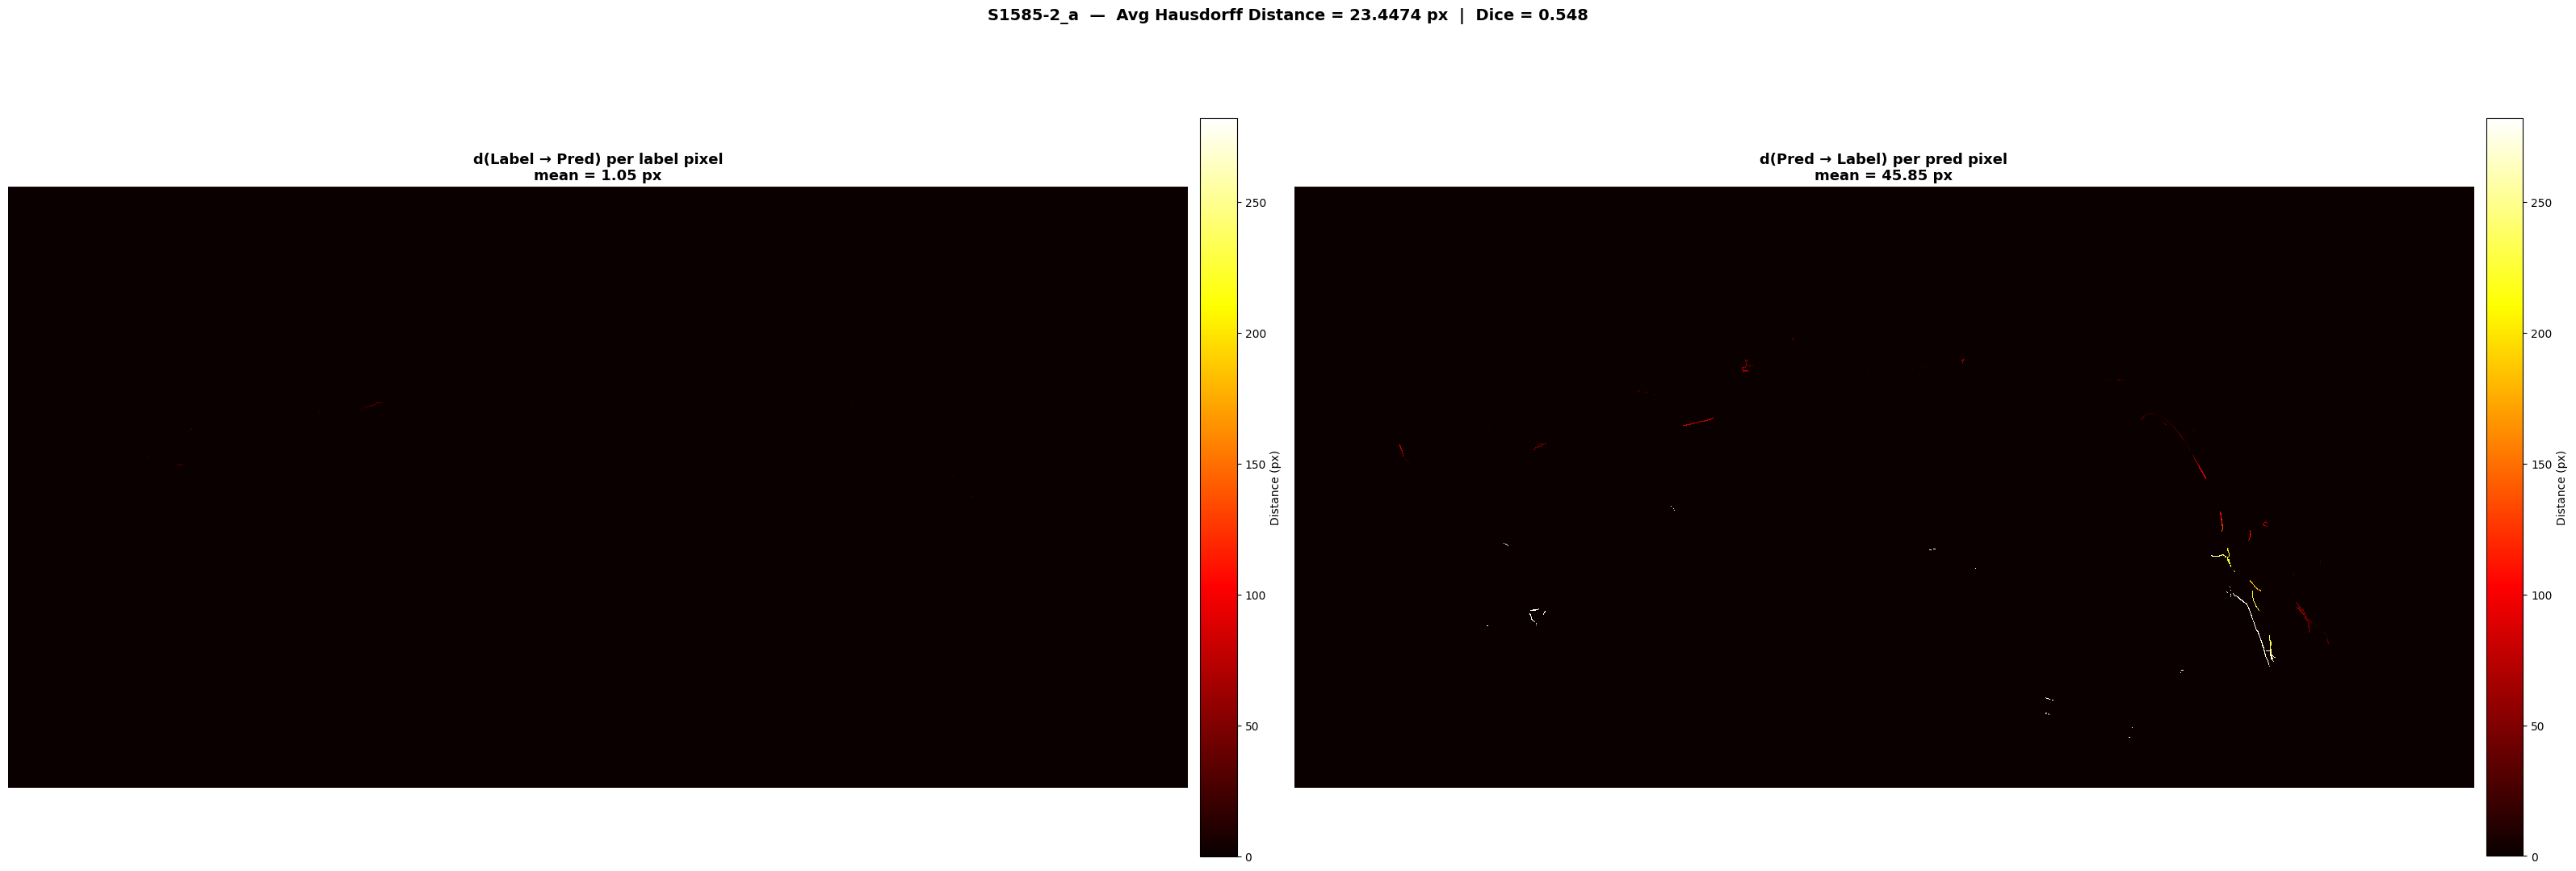

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(32, 12))

im0 = axes[0].imshow(
    dist_img_label, cmap="hot", vmin=0, vmax=vmax, interpolation="nearest"
)
axes[0].set_title(
    f"d(Label → Pred) per label pixel\nmean = {d_label_to_pred:.2f} px",
    fontsize=13, fontweight="bold"
)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.01, label="Distance (px)")

im1 = axes[1].imshow(
    dist_img_pred, cmap="hot", vmin=0, vmax=vmax, interpolation="nearest"
)
axes[1].set_title(
    f"d(Pred → Label) per pred pixel\nmean = {d_pred_to_label:.2f} px",
    fontsize=13, fontweight="bold"
)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.01, label="Distance (px)")

fig.suptitle(
    f"{SAMPLE_ID}  —  Avg Hausdorff Distance = {avg_hd:.4f} px"
    f"  |  Dice = {dice:.3f}",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8. Distance Distribution

In [ ]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

datasets = [
    (dist_label_to_pred, "d(GT → Pred)", d_label_to_pred, "#2196F3"),
    (dist_pred_to_label, "d(Pred → GT)", d_pred_to_label, "#FF5722"),
]

for ax, (dists, title, mean_val, color) in zip(axes, datasets):
    # Histogram
    ax.hist(dists, bins=100, density=True, color=color, alpha=0.4, label="Histogram")

    # KDE — clip to x >= 0
    x_max = np.percentile(dists, 99)
    x = np.linspace(0, x_max, 500)
    kde = gaussian_kde(dists, bw_method="scott")
    ax.plot(x, kde(x), color=color, linewidth=2, label="KDE")

    # Mean line
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_val:.2f} px")

    # Median line
    median_val = float(np.median(dists))
    ax.axvline(median_val, color="gray", linestyle=":", linewidth=1.5,
               label=f"Median = {median_val:.2f} px")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Distance (px)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_xlim(left=0)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"{SAMPLE_ID}  —  Per-pixel Distance Distribution",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8. Side-by-side Comparison

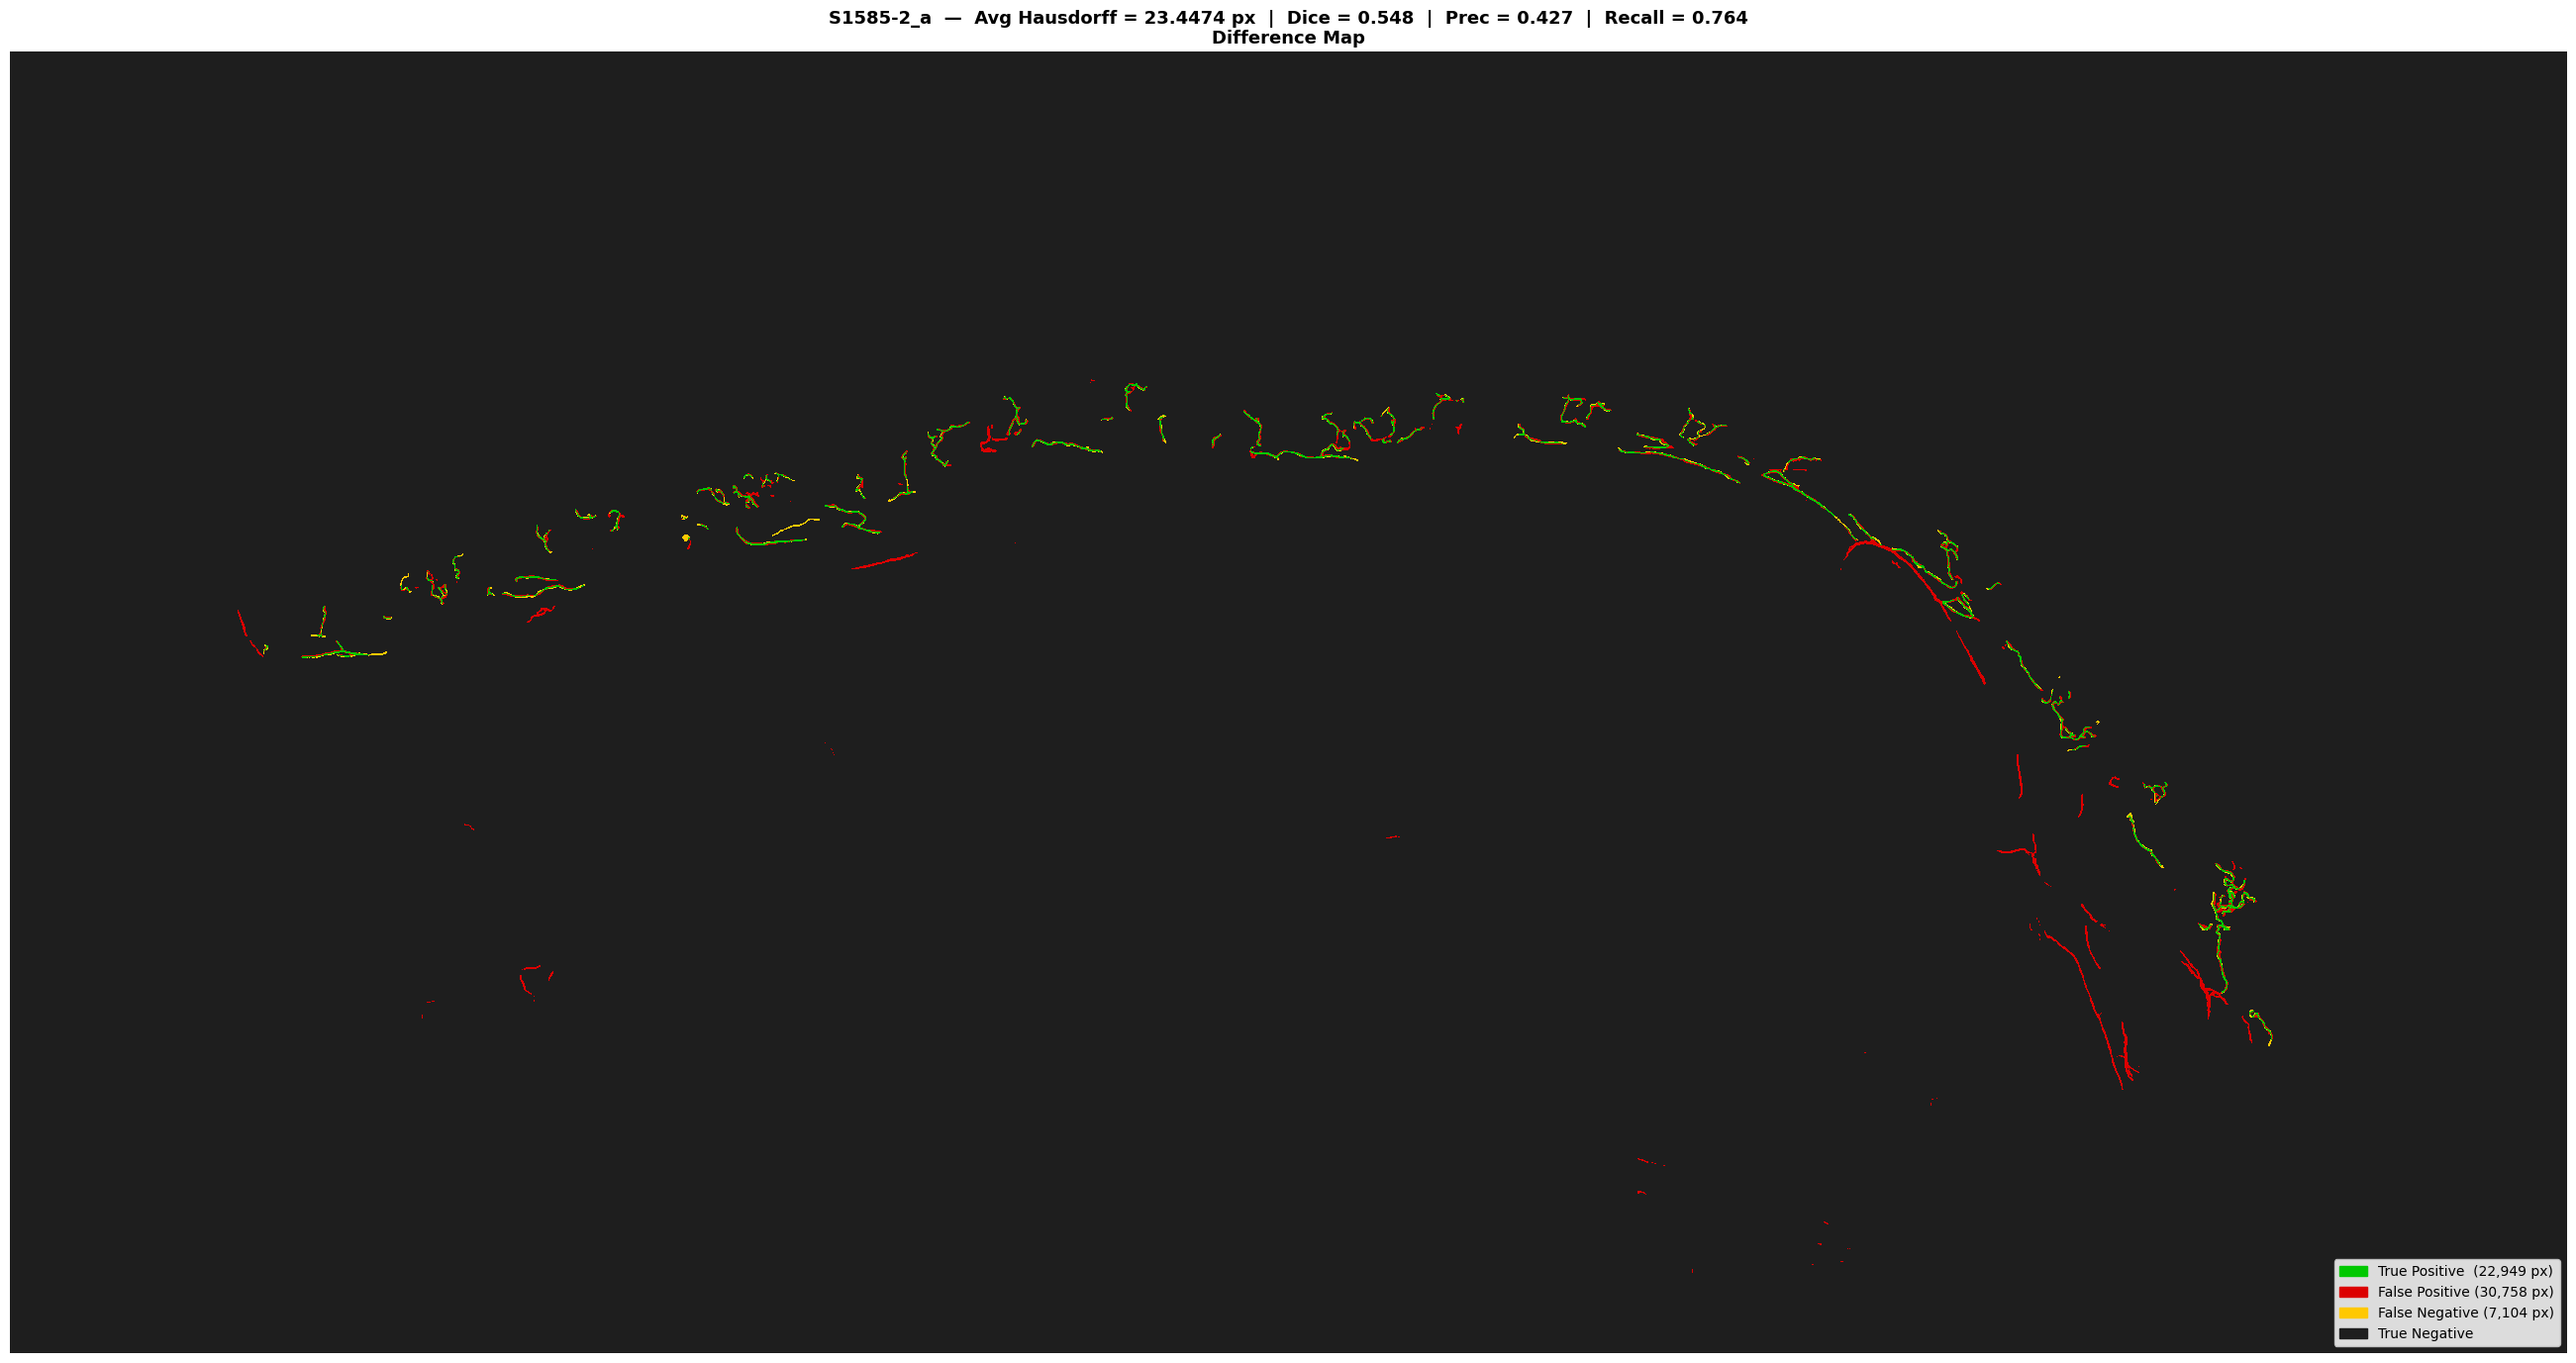

In [9]:
COLOR_TP = np.array([  0, 200,   0], dtype=np.uint8)  # green
COLOR_FP = np.array([220,   0,   0], dtype=np.uint8)  # red
COLOR_FN = np.array([255, 200,   0], dtype=np.uint8)  # yellow
COLOR_TN = np.array([ 30,  30,  30], dtype=np.uint8)  # dark gray

diff_map = np.empty((h, w, 3), dtype=np.uint8)
diff_map[ label_mask &  pred_mask] = COLOR_TP
diff_map[~label_mask &  pred_mask] = COLOR_FP
diff_map[ label_mask & ~pred_mask] = COLOR_FN
diff_map[~label_mask & ~pred_mask] = COLOR_TN

legend_patches = [
    mpatches.Patch(color=COLOR_TP / 255, label=f"True Positive  ({tp:,} px)"),
    mpatches.Patch(color=COLOR_FP / 255, label=f"False Positive ({fp:,} px)"),
    mpatches.Patch(color=COLOR_FN / 255, label=f"False Negative ({fn:,} px)"),
    mpatches.Patch(color=COLOR_TN / 255, label="True Negative"),
]

fig, ax = plt.subplots(figsize=(32, 14))
ax.imshow(diff_map, interpolation="nearest")
ax.set_title("Difference Map", fontsize=13, fontweight="bold")
ax.legend(handles=legend_patches, loc="lower right", fontsize=10, framealpha=0.85)
ax.axis("off")

fig.suptitle(
    f"{SAMPLE_ID}  —  Avg Hausdorff = {avg_hd:.4f} px"
    f"  |  Dice = {dice:.3f}"
    f"  |  Prec = {precision:.3f}"
    f"  |  Recall = {recall:.3f}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 9. Summary

In [10]:
print("=" * 50)
print(f"Sample: {SAMPLE_ID}")
print("=" * 50)
print(f"  Avg Hausdorff Distance  : {avg_hd:.4f} px")
print(f"    d(Pred  → Label)      : {d_pred_to_label:.4f} px")
print(f"    d(Label → Pred)       : {d_label_to_pred:.4f} px")
print("-" * 50)
print(f"  Dice Score              : {dice:.4f}")
print(f"  Precision               : {precision:.4f}")
print(f"  Recall                  : {recall:.4f}")
print(f"  IoU                     : {iou:.4f}")
print("=" * 50)

Sample: S1585-2_a
  Avg Hausdorff Distance  : 23.4474 px
    d(Pred  → Label)      : 45.8456 px
    d(Label → Pred)       : 1.0491 px
--------------------------------------------------
  Dice Score              : 0.5480
  Precision               : 0.4273
  Recall                  : 0.7636
  IoU                     : 0.3774
